In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#reddit_df = pd.read_csv('/home/jeremy/Teaching/intro_to_programming_and_ds/resources/data/100k_random_reddit_2018.csv')
reddit_df = pd.read_csv('../resources/data/100k_random_reddit_2018.csv')
reddit_df.created_utc = pd.to_datetime(reddit_df.created_utc, unit='s')
reddit_df = reddit_df.set_index('created_utc')

In [4]:
reddit_df

,subreddit,author,comment_length,score
created_utc,,,,
2018-01-01 00:00:41,Astronomy,illuminatiisnowhere,50,3
2018-01-01 00:02:52,politics,ExtracurricularSpork,31,10
2018-01-01 00:03:37,frugalmalefashion,TheBarnhouseEffect,126,5
2018-01-01 00:06:57,KansasCityChiefs,thenewguyreddit,48,5
2018-01-01 00:09:20,Aeon,ribnag,385,1
...,...,...,...,...
2018-12-31 23:50:40,Shamanism,[deleted],215,3
2018-12-31 23:51:04,funny,PCDuranet,40,60
2018-12-31 23:52:57,feludasports,ManyYoung,116,1


### Exercise 1

Sort the data frame by score and select the rows with the 10th to 20th highest scores.


In [23]:
reddit_df.sort_values('subreddit', ascending=False)[:10]

,subreddit,author,comment_length,score
created_utc,,,,
2018-08-15 15:37:52,zuckmemes,[deleted],9,-4
2018-09-03 22:14:44,zrxtrader,the-flying-acorn,598,1
2018-04-29 00:51:33,zootopia,jodyjm13,202,1
2018-02-01 04:34:06,zootopia,Krizman,8,1
2018-04-22 13:27:06,zootopia,McCannad,89,0
2018-08-19 10:32:15,zootopia,eng050599,676,5
2018-08-10 17:34:40,zootopia,TenderPaw64,243,1
2018-05-03 22:40:53,zoemains,Hyperduck420,50,2
2018-02-09 16:28:24,zoemains,Ngml,133,6


In [18]:
l = ['a','b','c','d','e']
l[1:3]

['b', 'c']

### Exercise 2

Now, how would you select just the `subreddit` and `comment_length` columns for the rows you selected above?

### Exercise 3

Find the average (mean) comment length for each subreddit and sort by comment length

### Exercise 4

Plot the number of comments and average score. Are frequent posters more likely to share comments that are well-received?

*Hint*: You will want to use a dataframe that groups the data by person

In [34]:
author_counts = reddit_df.groupby('author').score.count()
author_mean_scores = reddit_df.groupby('author').score.mean()
summarized_df = pd.DataFrame({'count':author_counts, 'mean_scores': author_mean_scores})

In [44]:
summarized_df = reddit_df.groupby('author').score.agg(['size', 'mean'])

In [52]:
summarized_df.loc[summarized_df['size'] < 1000]

,size,mean
author,,
---------_---------_,1,1.0
--------__--_---,1,1.0
-----_------_---,1,1.0
-----o____,1,7.0
----Prometheus----,1,2.0
...,...,...
zzoy,1,1.0
zzuum,1,1.0
zzyul,1,1.0


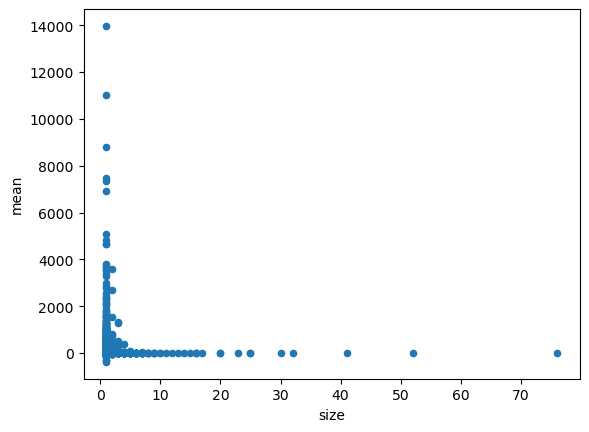

In [58]:
summarized_df.loc[summarized_df['size'] < 500].plot.scatter(x='size', y='mean');

### Exercise 5

Plot the number of comments per month over the year.

In [71]:
monthly = reddit_df.resample('ME').size()

<Axes: xlabel='created_utc'>

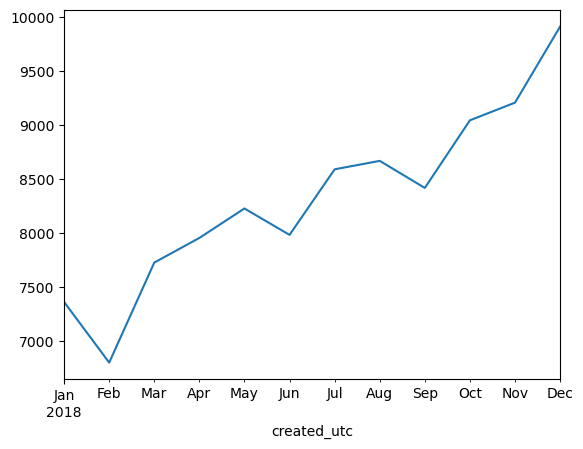

In [73]:
monthly.plot()

### Exercise 6

See if you can figure out how to change the above plot so that instead of showing one overall line for comments per hour, it shows a line for each day of the week (e.g., a line for comments per hour on Mondays, another for Tuesdays, etc.).

This code can help you to get started: it sums the number of comments by hour and day.

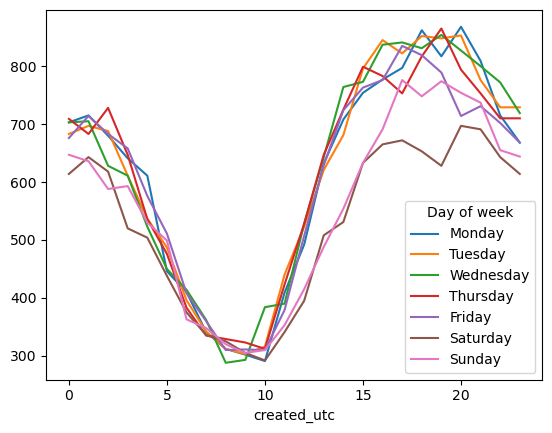

In [91]:
reddit_df.groupby([reddit_df.index.hour, reddit_df.index.weekday]).size().unstack().plot();
plt.legend(title='Day of week', labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

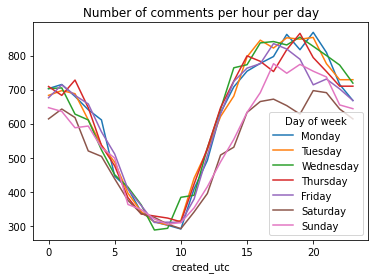

In [55]:
reddit_df.groupby([reddit_df.index.hour, reddit_df.index.day_of_week]).size().unstack().plot();
plt.title('Number of comments per hour per day')
plt.legend(title='Day of week', labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])